# N1 · 端到端训一个 mini-VLM (Train Mini-VLM)

> 配套 10.3-L1/L4 · 把 10.1 视觉塔 + 10.2 连接器 + tiny LLM 组装成 mini-VLM, 在合成视觉问答上训,
> 看 loss↓、准确率 0.25→~1.0, 再做**模态坍缩诊断** (空白图准确率掉不掉, L4)。

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import torch, numpy as np
import mini_vlm as mv
print('mini_vlm 就绪')

mini_vlm 就绪


## 1. 合成视觉问答数据 (L2 的「逼模型看图」)
每图属于 4 个视觉类别之一 (不同色块原型+噪声); VLM 收到固定指令「这是哪类」, 要输出类别。
视觉信息必须经连接器传给 LLM, 才能答对。

In [2]:
X, y, n_patch = mv.make_vqa_dataset(n_classes=4, n_per_class=16, img_size=8, seed=1)
print(f"数据: {X.shape[0]} 图, 4 类, 每图 {n_patch} patch, patch 维 {X.shape[2]}")
print(f"类别分布: {np.bincount(y)}")

数据: 64 图, 4 类, 每图 4 patch, patch 维 48
类别分布: [16 16 16 16]


## 2. 组装 + 训练 (两阶段简化版: 这里全解冻一起训, 看整链对齐)

可训练参数: 25332

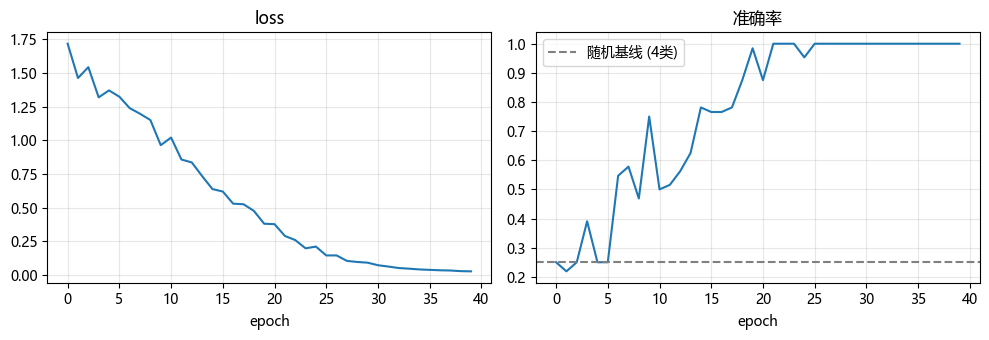

训练: loss 1.717→0.027; acc 0.25→1.00
→ VLM 学会了从图判类别: 视觉信息成功经连接器传给 LLM (整链对齐)。


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
torch.manual_seed(0)
model = mv.build_mini_vlm(patch_dim=X.shape[2], n_patch=n_patch, n_classes=4)
mv.set_freeze(model, freeze_vision=False, freeze_llm=False)
print(f"可训练参数: {mv.count_trainable(model)}")
loss, acc = mv.train_mini_vlm(model, X, y, epochs=40, lr=5e-3)
fig, axes = plt.subplots(1,2, figsize=(10,3.5))
axes[0].plot(loss); axes[0].set_title('loss'); axes[0].set_xlabel('epoch'); axes[0].grid(alpha=0.3)
axes[1].plot(acc); axes[1].axhline(0.25, ls='--', c='gray', label='随机基线 (4类)')
axes[1].set_title('准确率'); axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"训练: loss {loss[0]:.3f}→{loss[-1]:.3f}; acc {acc[0]:.2f}→{acc[-1]:.2f}")
print("→ VLM 学会了从图判类别: 视觉信息成功经连接器传给 LLM (整链对齐)。")

## 3. 模态坍缩诊断 (L4): VLM 真的在看图吗?

把测试图换成**空白图**和**打乱 patch 的图**, 看准确率是否掉到随机。
不掉 = 模型靠语言先验偷懒, 没在看图 (模态坍缩)。

In [4]:
import torch
with torch.no_grad():
    # 正常图
    acc_normal = (model(torch.tensor(X)).argmax(-1) == torch.tensor(y)).float().mean().item()
    # 空白图 (全 0)
    blank = torch.zeros_like(torch.tensor(X))
    acc_blank = (model(blank).argmax(-1) == torch.tensor(y)).float().mean().item()
    # 打乱每张图的 patch 顺序 (破坏空间结构)
    Xs = torch.tensor(X).clone()
    perm = torch.randperm(Xs.shape[1])
    acc_shuf = (model(Xs[:, perm]).argmax(-1) == torch.tensor(y)).float().mean().item()
print(f"正常图准确率:   {acc_normal:.2f}")
print(f"空白图准确率:   {acc_blank:.2f}  (掉到 ~0.25 随机 = 模型确实在看图 ✅)")
print(f"打乱图准确率:   {acc_shuf:.2f}")
print("\n→ 空白图准确率掉到随机, 说明这个 mini-VLM 真的依赖视觉 (没有模态坍缩)。")
print("→ 这个诊断是 VLM 版的'可证伪'(9.3): 声称用视觉的模型, 真用了吗?")

正常图准确率:   1.00
空白图准确率:   0.28  (掉到 ~0.25 随机 = 模型确实在看图 ✅)
打乱图准确率:   1.00

→ 空白图准确率掉到随机, 说明这个 mini-VLM 真的依赖视觉 (没有模态坍缩)。
→ 这个诊断是 VLM 版的'可证伪'(9.3): 声称用视觉的模型, 真用了吗?


## 4. 反思
你端到端训出了一个真能从图判类别的 mini-VLM, 并用「空白图诊断」确认它真在看图。带走:
- VLM 训练 = 让视觉信息经连接器真正传到 LLM (整链对齐), loss↓ acc↑ 是它发生的证据。
- 模态坍缩诊断 (空白图) 是检验「VLM 真用视觉吗」的关键, 接 9.3/10.6。
下一步 N2: 冻结策略消融 —— 冻 LLM 只训连接器, 还能学好吗?